In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
# disable while debugging native crashes:
# %load_ext autoreload
# %autoreload 2

In [2]:
import numpy as np, finufft

def smoke():
    M=2000
    x=np.ascontiguousarray(np.random.uniform(-np.pi,np.pi,M),dtype=np.float64)
    y=np.ascontiguousarray(np.random.uniform(-np.pi,np.pi,M),dtype=np.float64)
    c=np.ascontiguousarray(np.random.randn(M)+1j*np.random.randn(M),dtype=np.complex128)
    finufft.nufft2d1(x,y,c,(64,64),eps=1e-6,nthreads=1)

smoke(); print("finufft ok")

finufft ok


In [1]:
import numpy as np
import finufft

M = 20000
x = np.ascontiguousarray(np.random.uniform(-np.pi, np.pi, M), dtype=np.float64)
y = np.ascontiguousarray(np.random.uniform(-np.pi, np.pi, M), dtype=np.float64)
c = np.ascontiguousarray(np.random.randn(M) + 1j*np.random.randn(M), dtype=np.complex128)

out = finufft.nufft2d1(x, y, c, (128, 128), eps=1e-6, nthreads=1)
print(out.shape, np.isfinite(out).all())

(128, 128) True


In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [2]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
from cdshealpix import to_ring
import sys
sys.path.append("..")
#from healpix_analyse.powerspectra import powerspectra
from healpix_analyse.make_rectangle import make_healpix_rectangle_from_lonlat

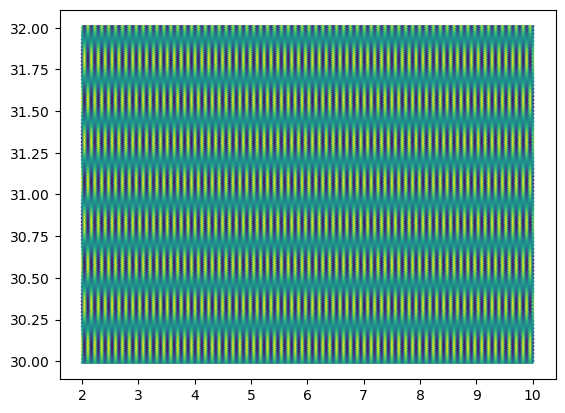

In [3]:
level = 12
ellipsoid = 'WGS84'

# Coverage box
lon_min, lon_max = 2.0, 10.0
lat_min, lat_max = 30.0, 32.0

cell_ids_2D_array = make_healpix_rectangle_from_lonlat(bbox=(lon_min, lat_min, lon_max, lat_max), 
                                                       level=level, 
                                                       ellipsoid=ellipsoid)

lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids_2D_array.flatten(), level, ellipsoid=ellipsoid)

def mock_data_function(lon, lat):
    definition = 20
    return np.cos(1024*(lon/definition + .1)) * np.sin(256*(lat/definition+.06)) + 0.5

data = mock_data_function(lon, lat)

plt.scatter(lon, lat, c=data, s=1)

In [4]:
cell_ids_2D_array

array([[50503771, 50503772, 50503773, ..., 50504133, 50504134, 50504135],
       [50487387, 50487388, 50487389, ..., 50487749, 50487750, 50487751],
       [50471003, 50471004, 50471005, ..., 50471365, 50471366, 50471367],
       ...,
       [47505499, 47505500, 47505501, ..., 47505861, 47505862, 47505863],
       [47489115, 47489116, 47489117, ..., 47489477, 47489478, 47489479],
       [47472731, 47472732, 47472733, ..., 47473093, 47473094, 47473095]],
      shape=(186, 365), dtype=uint64)

In [5]:
# reshape lat, lon, data as 2D array like cell_ids_2D_array
lat = lat.reshape(cell_ids_2D_array.shape)
lon = lon.reshape(cell_ids_2D_array.shape)
data = data.reshape(cell_ids_2D_array.shape)

In [6]:
import finufft

In [8]:
# ...existing code...
x = np.deg2rad(np.asarray(lat, dtype=np.float64).ravel())
y = np.deg2rad(np.asarray(lon, dtype=np.float64).ravel())
c = np.asarray(data, dtype=np.complex128).ravel()

# FINUFFT expects coords in [-pi, pi)
x = ((x + np.pi) % (2*np.pi)) - np.pi
y = ((y + np.pi) % (2*np.pi)) - np.pi

assert np.isfinite(x).all() and np.isfinite(y).all() and np.isfinite(c).all()

ms, mt = map(int, data.shape)
out = finufft.nufft2d1(x, y, c, (ms, mt), eps=1e-9, nthreads=1)
# ...existing code...

In [10]:
# FFT 2D non-uniforme
out = finufft.nufft2d1(lat.flatten(), lon.flatten(), 
                       np.asarray(data, dtype=np.complex128).flatten(), data.shape, debug=0)

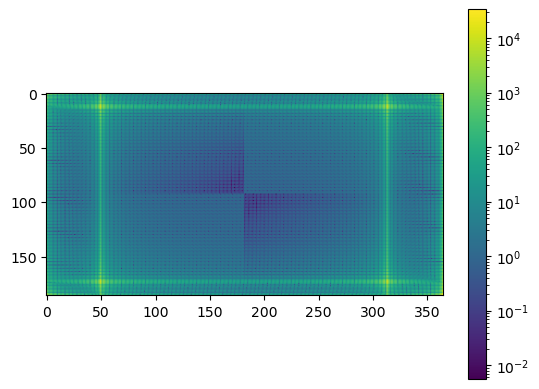

In [11]:
plt.imshow(np.fft.fftshift(np.abs(out)), norm='log')
plt.colorbar()

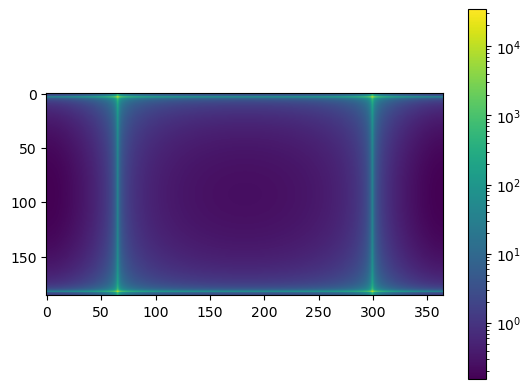

In [14]:
plt.imshow(np.abs(np.fft.fft2(data_latlon_grid)), norm='log')
plt.colorbar()

In [15]:
def ps(F_):

    F = np.fft.fftshift(F_)
    P2D = np.abs(F) ** 2

    if True:
        import matplotlib.pyplot as plt
        plt.imshow(P2D, norm='log')
        plt.colorbar(label='Power (log scale)', orientation='horizontal')
        plt.show()

    # Spatial frequency grids (cycles per unit length; NOT radians)
    ny, nx = P2D.shape
    fx = np.fft.fftshift(np.fft.fftfreq(nx))  # cycles per unit length (e.g., m^-1)
    fy = np.fft.fftshift(np.fft.fftfreq(ny))  # cycles per unit length (e.g., m^-1)
    fx2d, fy2d = np.meshgrid(fx, fy, indexing="xy")
    fr = np.sqrt(fx2d**2 + fy2d**2)  # radial spatial frequency (cycles per unit length)

    # Radial binning
    nbins = min(nx, ny) // 2
    f_bins = np.linspace(0.0, fr.max(), nbins + 1)

    # Vectorized bin average of P2D over annuli
    fr_flat = fr.ravel()
    P_flat = P2D.ravel()
    bin_idx = np.digitize(fr_flat, f_bins) - 1  # -> [0, nbins-1]
    valid = (bin_idx >= 0) & (bin_idx < nbins)

    # Sum and count per bin, then mean
    sum_per_bin = np.bincount(bin_idx[valid], weights=P_flat[valid], minlength=nbins)
    cnt_per_bin = np.bincount(bin_idx[valid], minlength=nbins)
    with np.errstate(invalid="ignore", divide="ignore"):
        Pk = sum_per_bin / cnt_per_bin
    Pk[cnt_per_bin == 0] = np.nan  # empty bins

    # Bin centers
    f_centers = 0.5 * (f_bins[1:] + f_bins[:-1])

    return f_centers, Pk/(nx*ny)

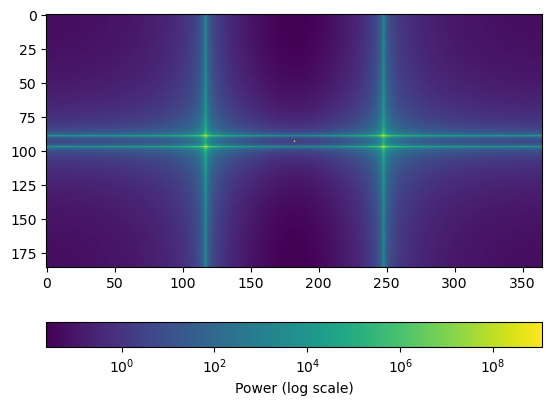

In [16]:
nu_latlon_grid, cl_latlon_grid = ps(np.fft.fft2(data_latlon_grid))

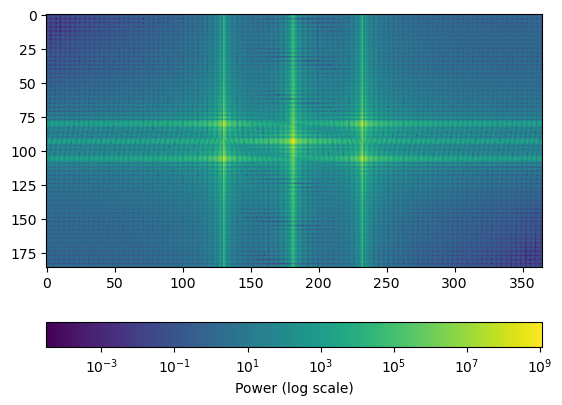

In [17]:
nu, cl = ps(np.fft.fftshift(out))

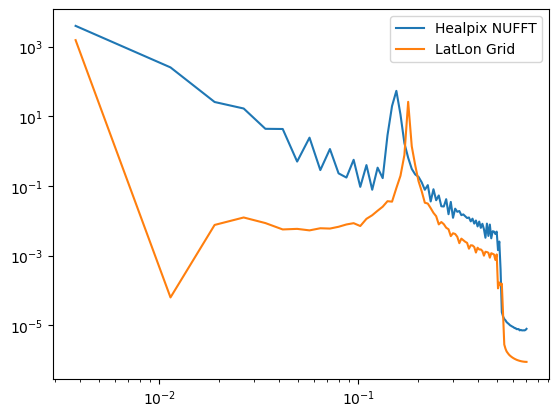

In [19]:
plt.plot(nu, cl, label='Healpix NUFFT')
plt.plot(nu_latlon_grid, cl_latlon_grid, label='LatLon Grid')
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [21]:
lon_new = np.zeros_like(lon) 
lon_new[::2,:] = lon[::2,:]  
lon_new[1::2,:] = lon[::2,:] + .5 * (lon[0,-1] - lon[0,0]) / lon.shape[1]

In [22]:
data = mock_data_function(lon_new, lat)

In [6]:
cell_ids_2D_array.shape

(186, 365)

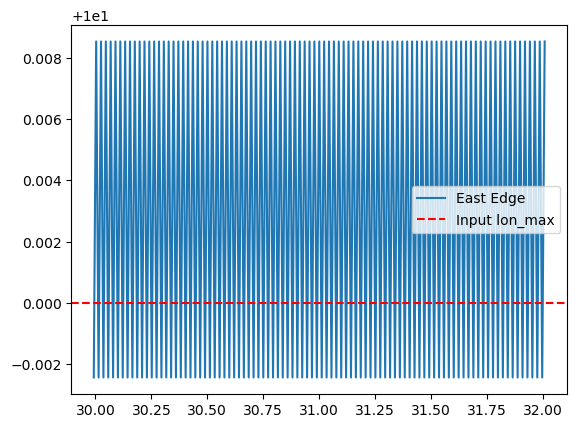

In [7]:
#plt.plot(lat[:,0], lon.min(axis=-1), label='West Edge')
#plt.axhline(y=lon_min, label='Input lon_min', color='red', linestyle='--')
plt.plot(lat[:,0], lon.max(axis=-1), label='East Edge')
plt.axhline(y=lon_max, label='Input lon_max', color='red', linestyle='--')

plt.xlim()
plt.legend()
plt.show()

In [12]:
lon_grid, lat_grid = np.meshgrid(np.linspace(lon_min, lon_max, cell_ids_2D_array.shape[1]),
                                 np.linspace(lat_min, lat_max, cell_ids_2D_array.shape[0]))

In [13]:
data_latlon_grid = mock_data_function(lon_grid, lat_grid)
data_latlon_grid

array([[ 0.80512718,  0.44453652,  0.14707122, ...,  0.83029383,
         0.79041767,  0.42000474],
       [ 0.9082836 ,  0.4257856 ,  0.02775418, ...,  0.94195851,
         0.88860114,  0.3929602 ],
       [ 1.00363444,  0.40845352, -0.08253444, ...,  1.04517381,
         0.97935533,  0.36796205],
       ...,
       [ 0.94521803,  0.41907197, -0.01496644, ...,  0.98193927,
         0.92375505,  0.38327709],
       [ 1.03714687,  0.40236191, -0.12129697, ...,  1.08145032,
         1.0112522 ,  0.35917609],
       [ 1.11880652,  0.3875185 , -0.21574951, ...,  1.16984519,
         1.08897521,  0.33776736]], shape=(186, 365))

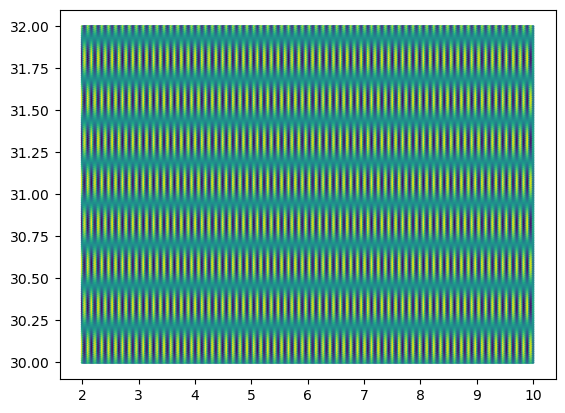

In [14]:
plt.scatter(lon_grid.flatten(), lat_grid.flatten(), c=data_latlon_grid.flatten(), s=1)

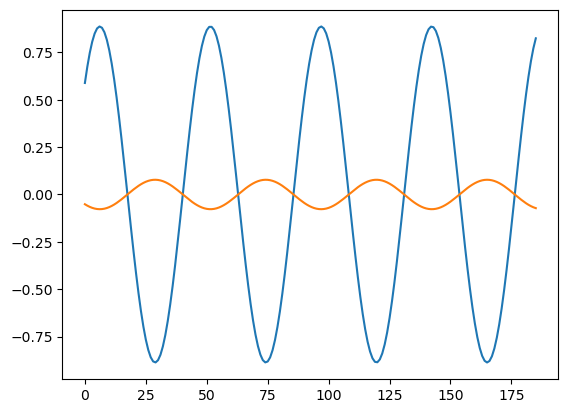

In [14]:
compare = np.fft.fft(data_latlon_grid, axis=-1)
plt.plot(compare[:, 130].real)
plt.plot(compare[:, 130].imag)
plt.show()

lon_range 7.998046875
self.n_lon 365
self.lons_of_western_edge - self.lons_of_western_edge.min() tensor([0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110,
        0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110,
        0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110,
        0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110,
        0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110,
        0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000, 0.0110, 0.0000,
        0.0110, 0.0000,

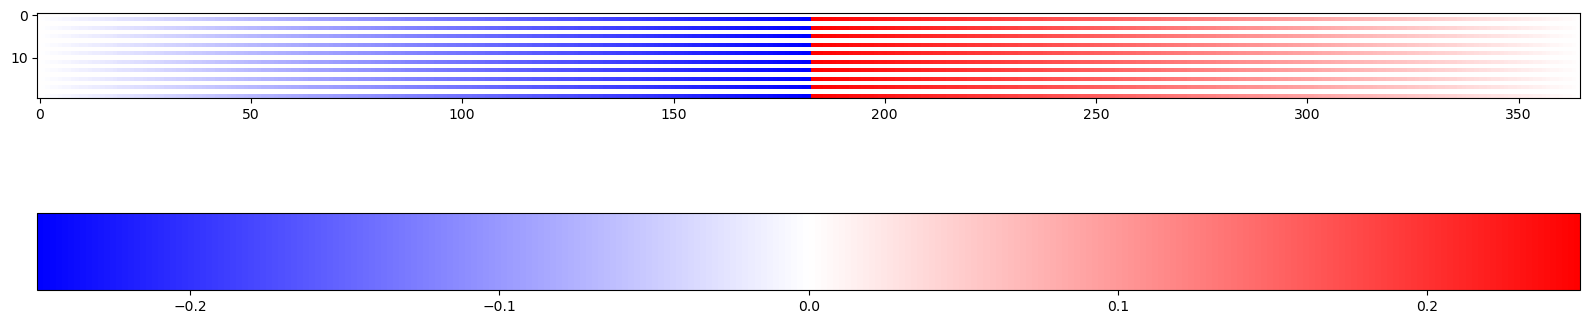

data input tensor([[ 0.7350,  0.4650,  0.2349,  ...,  0.7328,  0.7397,  0.4739],
        [ 0.6735,  0.2409,  0.1030,  ...,  0.9086,  0.6853,  0.2511],
        [ 0.9461,  0.4335, -0.0035,  ...,  0.9420,  0.9551,  0.4504],
        ...,
        [ 0.7590,  0.1132, -0.0926,  ...,  1.1100,  0.7766,  0.1285],
        [ 1.1017,  0.4103, -0.1790,  ...,  1.0962,  1.1138,  0.4331],
        [ 0.8423, -0.0112, -0.2831,  ...,  1.3061,  0.8655,  0.0090]],
       device='mps:0')
data corrected tensor([[ 0.7350,  0.4650,  0.2349,  ...,  0.7328,  0.7397,  0.4739],
        [ 0.6735,  0.4572,  0.1720,  ...,  0.7879,  0.7970,  0.4682],
        [ 0.9461,  0.4335, -0.0035,  ...,  0.9420,  0.9551,  0.4504],
        ...,
        [ 0.7590,  0.4361,  0.0103,  ...,  0.9297,  0.9433,  0.4525],
        [ 1.1017,  0.4103, -0.1790,  ...,  1.0962,  1.1138,  0.4331],
        [ 0.8423,  0.4155, -0.1471,  ...,  1.0679,  1.0858,  0.4373]],
       device='mps:0')


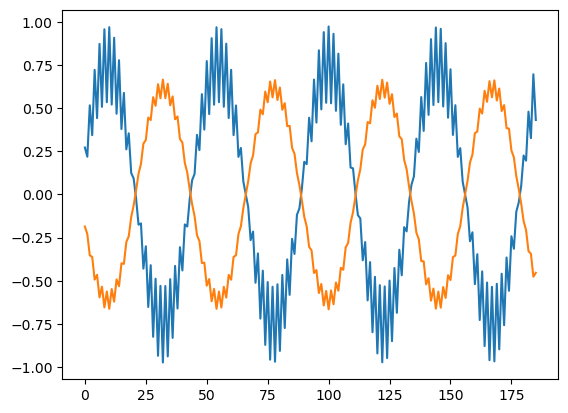

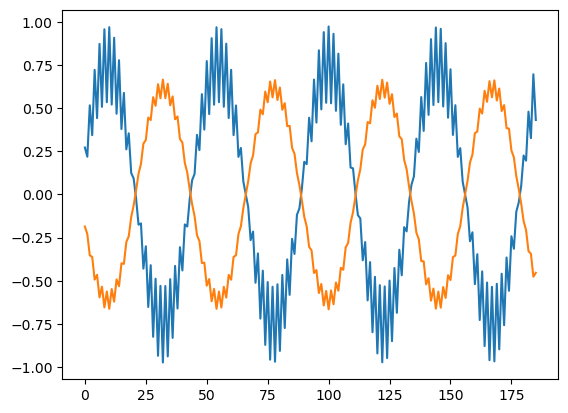

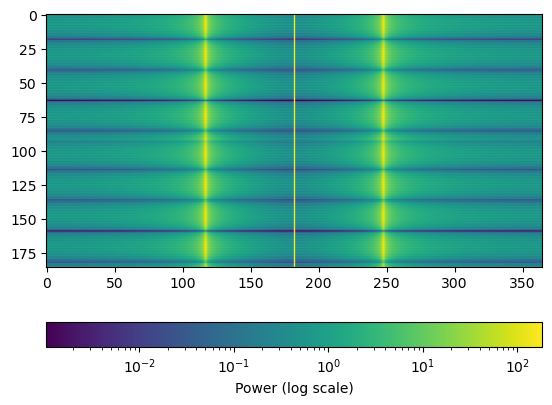

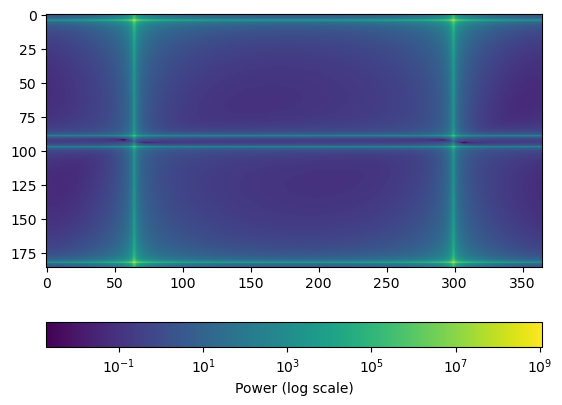

In [23]:
nu, cl = powerspectra(cell_ids_2D_array, level, data, indexing_scheme='2D_array', plot_2D_fft=True)

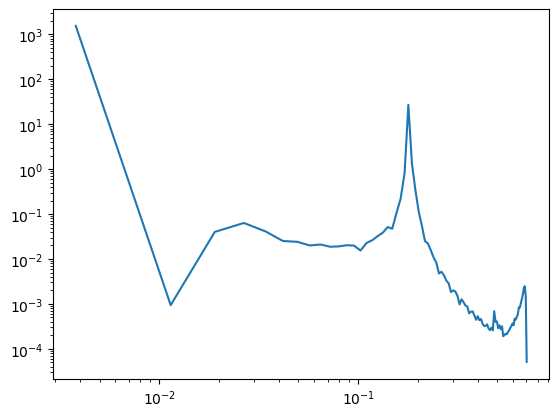

In [12]:
plt.plot(nu, cl)
plt.yscale('log')
plt.xscale('log')

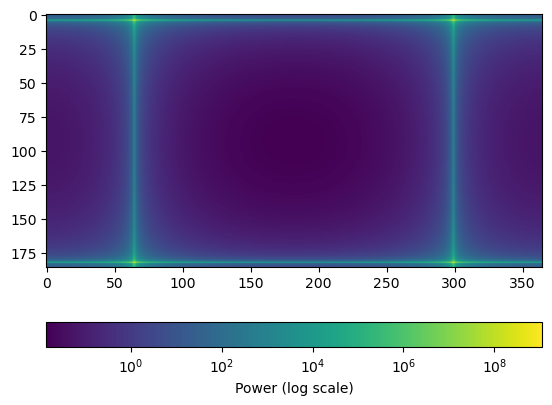

In [13]:
import torch
nu_latlon_grid, cl_latlon_grid = powerspectra(None, None, None, 
                                              ltf=torch.fft.fft2(torch.as_tensor(data_latlon_grid)),
                                              plot_2D_fft=True)

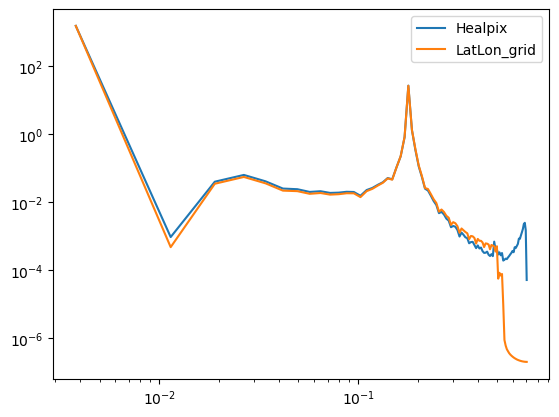

In [14]:
plt.plot(nu, cl, label='Healpix')
plt.plot(nu_latlon_grid, cl_latlon_grid, label='LatLon_grid')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

In [15]:
lats = np.unique(lat)
lons = np.unique(lon)

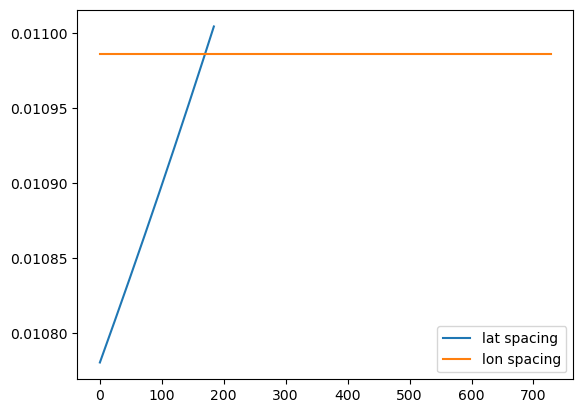

In [16]:
plt.plot(np.diff(lats), label='lat spacing')
plt.plot(np.diff(lons), label='lon spacing')
plt.legend()
plt.show()

In [17]:
import pyproj
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ==========================================
# 1. Project to UTM and Interpolate
# ==========================================
# Approximate pixel size for HEALPix level 12 is ~1580 meters
grid_resolution_meters = 1580.0  

print("Projecting to UTM Zone 31N...")
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32631", always_xy=True)
utm_x, utm_y = transformer.transform(lon, lat)

print("Interpolating data onto regular grid...")
xi = np.arange(utm_x.min(), utm_x.max(), grid_resolution_meters)
yi = np.arange(utm_y.min(), utm_y.max(), grid_resolution_meters)
XI, YI = np.meshgrid(xi, yi)

grid_data = griddata((utm_x, utm_y), data, (XI, YI), method='linear')

# Fill NaNs (outside the boundary) with the mean value to avoid FFT errors
mean_val = np.nanmean(grid_data)
grid_data_filled = np.nan_to_num(grid_data, nan=mean_val)

# Remove the mean to eliminate the massive spike at frequency 0
grid_data_centered = grid_data_filled - mean_val

# ==========================================
# 2. Apply 2D Windowing to prevent Spectral Leakage
# ==========================================
ny, nx = grid_data_centered.shape

# Create a 2D Hanning window that tapers the edges smoothly to zero
hy = np.hanning(ny)
hx = np.hanning(nx)
window_2d = np.outer(hy, hx)

# Multiply our centered data by the window
grid_data_windowed = grid_data_centered * window_2d

# ==========================================
# 3. Compute the Windowed 2D FFT & Radial Average
# ==========================================
fft2d_shifted = np.fft.fftshift(np.fft.fft2(grid_data_windowed))
power_spectrum_2d = np.abs(fft2d_shifted)**2

# Get radial distances from center
y_idx, x_idx = np.indices(power_spectrum_2d.shape)
center_y, center_x = ny // 2, nx // 2
radius = np.sqrt((x_idx - center_x)**2 + (y_idx - center_y)**2).astype(int)

# Bin and average
power_sum = np.bincount(radius.ravel(), power_spectrum_2d.ravel())
pixels_in_bin = np.bincount(radius.ravel())

valid_bins = pixels_in_bin > 0
power_1d_cartesian = np.zeros_like(power_sum)
power_1d_cartesian[valid_bins] = power_sum[valid_bins] / pixels_in_bin[valid_bins]

# Calculate physical Cartesian spatial frequencies (cycles per meter)
max_freq = 1.0 / (2 * grid_resolution_meters)
freqs_cartesian = np.linspace(0, max_freq, len(power_1d_cartesian))

# ==========================================
# 4. Compare with your HEALPix-Analyse script
# ==========================================
print("Computing native spherical power spectrum...")

# CRITICAL FIX: Pass dx=grid_resolution_meters here so the units match!
nu_spherical, cl_spherical = powerspectra(cell_ids_2D_array, 
                                          level, 
                                          data, 
                                          indexing_scheme='2D_array', 
                                          plot_2D_fft=True)

# Normalize both Y-axes so their shapes can be compared directly
# (We slice from [1:] to safely ignore any residual DC/Zero-frequency offsets)
power_1d_cart_norm = power_1d_cartesian / np.max(power_1d_cartesian[1:])
cl_spherical_norm = cl_spherical / np.max(cl_spherical[1:])

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(nu_spherical, cl_spherical_norm, 
         label="healpix-analyse (Native Spherical)", color='red', linewidth=2)

plt.plot(freqs_cartesian, power_1d_cart_norm, 
         label="UTM Interpolated + Windowed FFT", color='blue', linestyle='--', linewidth=2)

plt.title("Power Spectrum Comparison (Harmonized X-Axis)")
plt.xlabel("Spatial Frequency (cycles / meter)")
plt.ylabel("Normalized Power")

# Log scales help reveal the peak alignments and noise floors
plt.yscale('log')
plt.xscale('log')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'pyproj'